## TASK 3
### TRANFER LEARNING

### 1) Rotation of 30 Degrees

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

# setup
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 10
N_TRANSFER = 300   # few-shot setting


# CNN from Task 1
class CNNNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# training and evaluation
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        pred = out.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return total_loss / total, correct / total

def evaluate(model, loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return loss_sum / total, correct / total

# original Dataset from Task 1 
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Now rotated for new Task (rot of 30 degrees)
transform_rotated = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_full = datasets.MNIST("data", train=True, download=True, transform=transform_rotated)
test_rotated = datasets.MNIST("data", train=False, download=True, transform=transform_rotated)

# few-shot subset
indices = torch.randperm(len(train_full))[:N_TRANSFER]
train_rotated_small = Subset(train_full, indices)

train_loader_small = DataLoader(train_rotated_small, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_rotated, batch_size=256, shuffle=False)

criterion = nn.CrossEntropyLoss()

# original model evaluated on rotated task
model_a = CNNNet().to(device)
model_a.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))
_, acc_a = evaluate(model_a, test_loader)

# now train from scratch on few rotated samples
model_b = CNNNet().to(device)
optimizer_b = optim.Adam(model_b.parameters(), lr=LR)

train_losses_b, train_accs_b = [], []
test_losses_b, test_accs_b = [], []

for _ in range(EPOCHS):
    tr_loss, tr_acc = train(model_b, train_loader_small, optimizer_b, criterion)
    te_loss, te_acc = evaluate(model_b, test_loader)
    train_losses_b.append(tr_loss)
    train_accs_b.append(tr_acc)
    test_losses_b.append(te_loss)
    test_accs_b.append(te_acc)

acc_b = test_accs_b[-1]

# now transfer learning
model_c = CNNNet().to(device)
model_c.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))

for param in model_c.conv1.parameters():
    param.requires_grad = False
for param in model_c.conv2.parameters():
    param.requires_grad = False

optimizer_c = optim.Adam(
    filter(lambda p: p.requires_grad, model_c.parameters()),
    lr=LR
)

train_losses_c, train_accs_c = [], []
test_losses_c, test_accs_c = [], []

for _ in range(EPOCHS):
    tr_loss, tr_acc = train(model_c, train_loader_small, optimizer_c, criterion)
    te_loss, te_acc = evaluate(model_c, test_loader)
    train_losses_c.append(tr_loss)
    train_accs_c.append(tr_acc)
    test_losses_c.append(te_loss)
    test_accs_c.append(te_acc)

acc_c = test_accs_c[-1]

# results
print("Results ")
print(f"(a) original model, no adaptation:   {acc_a*100:.2f}%")
print(f"(b) trained from scratch (few data): {acc_b*100:.2f}%")
print(f"(c) transfer learning:               {acc_c*100:.2f}%")


Results 
(a) original model, no adaptation:   93.54%
(b) trained from scratch (few data): 84.54%
(c) transfer learning:               95.69%


#### Plot

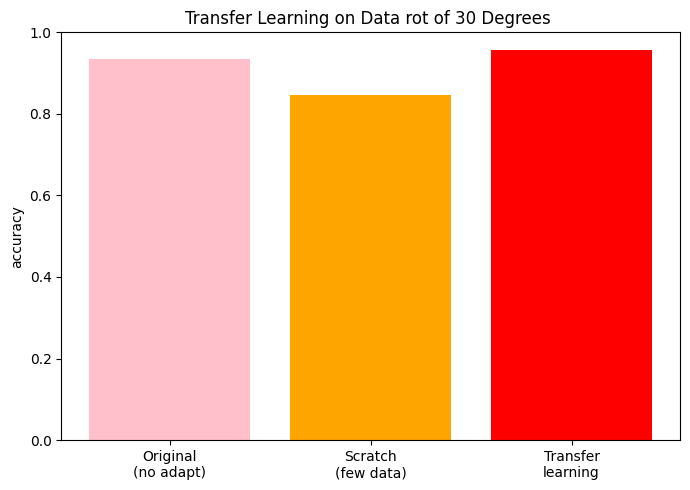

In [6]:
# bar plot
labels = ["Original\n(no adapt)", "Scratch\n(few data)", "Transfer\nlearning"]
accuracies = [acc_a, acc_b, acc_c]

plt.figure(figsize=(7, 5))
plt.bar(
    labels,
    accuracies,
    color=["pink", "orange", "red"]
)
plt.ylabel("accuracy")
plt.title("Transfer Learning on Data rot of 30 Degrees ")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("transfer_learning_results.png", dpi=300)
plt.show()


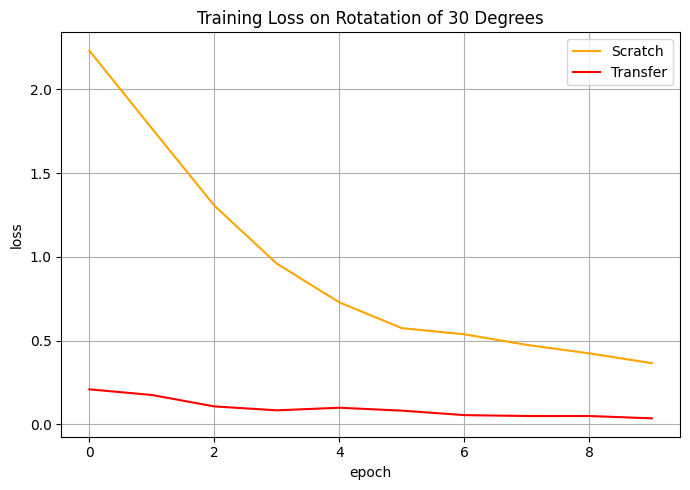

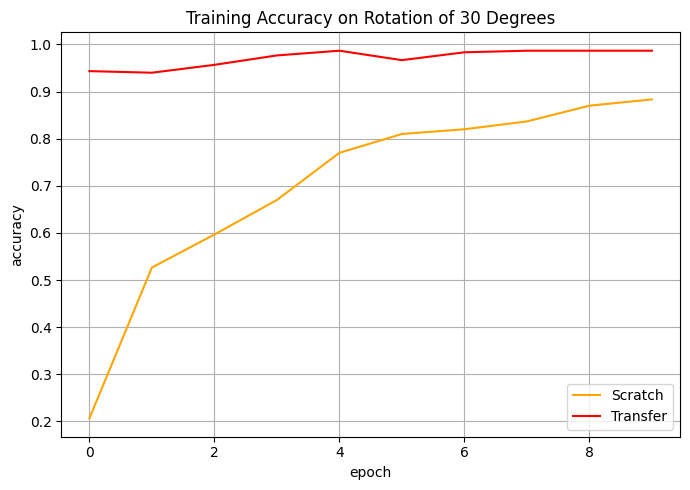

In [8]:
# training curves on rotated task (30 degrees)

def train_with_history(model, loader, optimizer, criterion, epochs):
    train_loss = []
    train_acc = []

    for _ in range(epochs):
        model.train()
        correct = 0
        total = 0
        loss_sum = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        train_loss.append(loss_sum / len(loader))
        train_acc.append(correct / total)

    return train_loss, train_acc


# scratch model curves
model_b_curve = CNNNet().to(device)
optimizer_b_curve = optim.Adam(model_b_curve.parameters(), lr=LR)
loss_b, acc_b_curve = train_with_history(
    model_b_curve, train_loader_small, optimizer_b_curve, criterion, EPOCHS
)

# transfer model curves
model_c_curve = CNNNet().to(device)
model_c_curve.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))

for param in model_c_curve.conv1.parameters():
    param.requires_grad = False
for param in model_c_curve.conv2.parameters():
    param.requires_grad = False

optimizer_c_curve = optim.Adam(
    filter(lambda p: p.requires_grad, model_c_curve.parameters()), lr=LR
)

loss_c, acc_c_curve = train_with_history(
    model_c_curve, train_loader_small, optimizer_c_curve, criterion, EPOCHS
)


# plot loss
plt.figure(figsize=(7, 5))
plt.plot(loss_b, label="Scratch", color="orange")
plt.plot(loss_c, label="Transfer", color="red")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss on Rotatation of 30 Degrees")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transfer_training_loss_30deg.png", dpi=300)
plt.show()

# plot accuracy
plt.figure(figsize=(7, 5))
plt.plot(acc_b_curve, label="Scratch", color="orange")
plt.plot(acc_c_curve, label="Transfer", color="red")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training Accuracy on Rotation of 30 Degrees")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transfer_training_accuracy_30deg.png", dpi=300)
plt.show()


### 2) Rotation of 90 Degrees

In [12]:
# Now we try with  90-degree rotation 
transform_rotated_90 = transforms.Compose([
    transforms.RandomRotation((90, 90)),   # always 90 degrees
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# datasets
train_full_90 = datasets.MNIST(
    "data", train=True, download=True, transform=transform_rotated_90
)
test_rotated_90 = datasets.MNIST(
    "data", train=False, download=True, transform=transform_rotated_90
)

# few-shot subset
indices_90 = torch.randperm(len(train_full_90))[:N_TRANSFER]
train_rotated_90_small = Subset(train_full_90, indices_90)

train_loader_90_small = DataLoader(
    train_rotated_90_small, batch_size=BATCH_SIZE, shuffle=True
)
test_loader_90 = DataLoader(
    test_rotated_90, batch_size=256, shuffle=False
)

# original model 
model_a_90 = CNNNet().to(device)
model_a_90.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))
_, acc_a_90 = evaluate(model_a_90, test_loader_90)

# Now rotated for new Task (rot of 90 degrees)
model_b_90 = CNNNet().to(device)
optimizer_b_90 = optim.Adam(model_b_90.parameters(), lr=LR)

for _ in range(EPOCHS):
    train(model_b_90, train_loader_90_small, optimizer_b_90, criterion)

_, acc_b_90 = evaluate(model_b_90, test_loader_90)

# now transfer learning
model_c_90 = CNNNet().to(device)
model_c_90.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))

for param in model_c_90.conv1.parameters():
    param.requires_grad = False
for param in model_c_90.conv2.parameters():
    param.requires_grad = False

optimizer_c_90 = optim.Adam(
    filter(lambda p: p.requires_grad, model_c_90.parameters()),
    lr=LR
)

for _ in range(EPOCHS):
    train(model_c_90, train_loader_90_small, optimizer_c_90, criterion)

_, acc_c_90 = evaluate(model_c_90, test_loader_90)


# Results
print("\n Results rot of 90 deg")
print(f"(a) original model, no adaptation:   {acc_a_90*100:.2f}%")
print(f"(b) trained from scratch (few data): {acc_b_90*100:.2f}%")
print(f"(c) transfer learning:               {acc_c_90*100:.2f}%")



 Results rot of 90 deg
(a) original model, no adaptation:   15.99%
(b) trained from scratch (few data): 87.25%
(c) transfer learning:               90.38%


#### Plot 

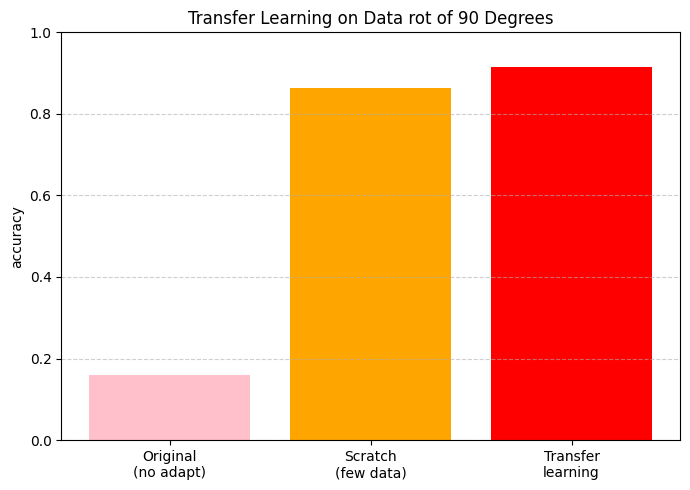

In [9]:
# Plot
labels = ["Original\n(no adapt)", "Scratch\n(few data)", "Transfer\nlearning"]
accs_90 = [acc_a_90, acc_b_90, acc_c_90]

plt.figure(figsize=(7, 5))
plt.bar(labels, accs_90, color=["pink",'orange', "red"])
plt.ylim(0, 1.0)
plt.ylabel("accuracy")
plt.title("Transfer Learning on Data rot of 90 Degrees")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("transfer_learning_rotated_90.png", dpi=300)
plt.show()

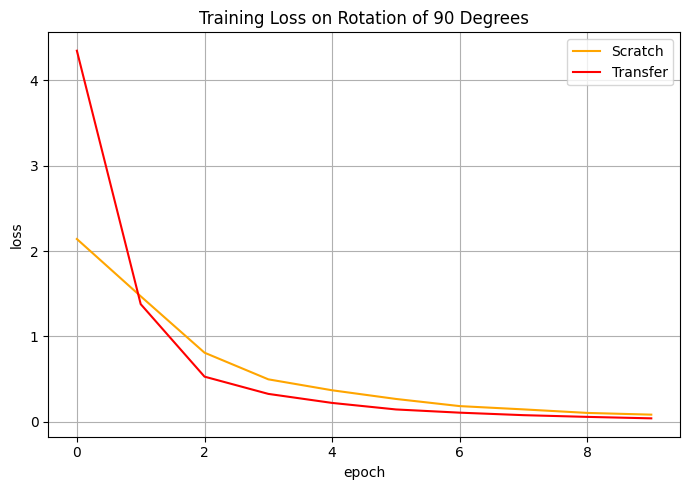

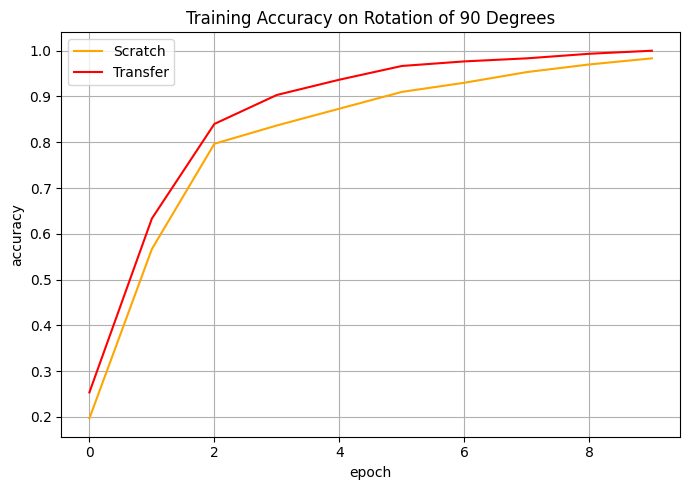

In [13]:
# training curves on rotated task (90 degrees)

def train_with_history(model, loader, optimizer, criterion, epochs):
    train_loss = []
    train_acc = []

    for _ in range(epochs):
        model.train()
        correct = 0
        total = 0
        loss_sum = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

        train_loss.append(loss_sum / len(loader))
        train_acc.append(correct / total)

    return train_loss, train_acc


# scratch model curves
model_b_90_curve = CNNNet().to(device)
optimizer_b_90_curve = optim.Adam(model_b_90_curve.parameters(), lr=LR)
loss_b_90, acc_b_90_curve = train_with_history(
    model_b_90_curve, train_loader_90_small, optimizer_b_90_curve, criterion, EPOCHS
)

# transfer model curves
model_c_90_curve = CNNNet().to(device)
model_c_90_curve.load_state_dict(torch.load("cnn_best_model.pth", map_location=device))

for param in model_c_90_curve.conv1.parameters():
    param.requires_grad = False
for param in model_c_90_curve.conv2.parameters():
    param.requires_grad = False

optimizer_c_90_curve = optim.Adam(
    filter(lambda p: p.requires_grad, model_c_90_curve.parameters()), lr=LR
)

loss_c_90, acc_c_90_curve = train_with_history(
    model_c_90_curve, train_loader_90_small, optimizer_c_90_curve, criterion, EPOCHS
)


# plot loss
plt.figure(figsize=(7, 5))
plt.plot(loss_b_90, label="Scratch", color="orange")
plt.plot(loss_c_90, label="Transfer", color="red")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss on Rotation of 90 Degrees")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transfer_training_loss_90deg.png", dpi=300)
plt.show()

# plot accuracy
plt.figure(figsize=(7, 5))
plt.plot(acc_b_90_curve, label="Scratch", color="orange")
plt.plot(acc_c_90_curve, label="Transfer", color="red")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Training Accuracy on Rotation of 90 Degrees")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("transfer_training_accuracy_90deg.png", dpi=300)
plt.show()
